# Filtering in the frequency domain
## Ideal (FFT-mask) vs. realizable (Butterworth) filtering
A band-limited test signal is built via the iFFT, then filtered two ways: by an ideal brick-wall mask applied to the FFT, and by a Butterworth filter applied in the time domain.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

from scipy.signal import chirp, spectrogram, windows, butter, filtfilt, freqz, lfilter
from scipy.fftpack import fft, ifft, fftfreq, fftshift, ifftshift
from scipy.io.wavfile import write 

## Flat Spectrum - Set Parameters 

In [4]:
Td = 2
fs = 44100
N = 2**(1+round(np.log2(Td*fs)))
#N = 4096; 
print('N = '+str(N))
T = N/fs
t = np.arange(N)*T/N
delta_freq = fs/N

N = 131072


In [5]:
# bounds of rect in Y(f)
f_low = 1000
f_high = 4000
# find equivalent positions in Y(f) 
n_low = int(f_low/delta_freq)
n_high = int(f_high/delta_freq)
L1 = np.arange(n_low,n_high)

## Create Y(f) and y[n]

In [6]:
Y_bl = np.zeros((N,), dtype=complex)
# create random phase needed for correct ifft process
rng = np.random.default_rng()
phi = rng.uniform(0, 2*np.pi, (len(L1),))

# create Y(f)
mag_temp = np.ones([1,n_high-n_low])
    
Y_bl[L1] = mag_temp*np.exp(1j*phi)
# add complex conjugate at upper end to ensure that y[n] real
Y_bl[N-L1] = np.conj(Y_bl[L1])

# create y[n]
y_bl = ifft(Y_bl)

## FFT the created data to confirm spectrum is right

In [7]:
Y_bl_fft = fft(y_bl)
f_bl = fftfreq(N, 1/fs)

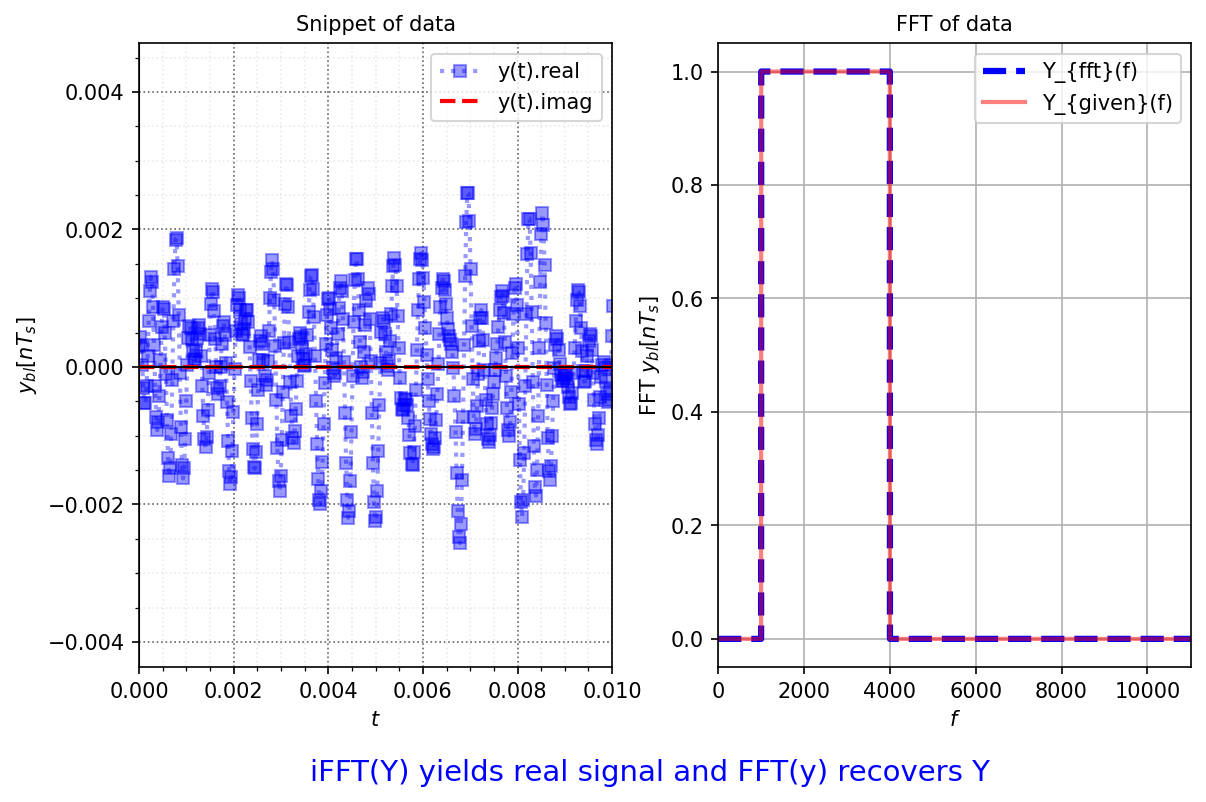

In [8]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,5), dpi=150)
fig.tight_layout(pad=2)
ax1.plot(t[0:n_low], y_bl.real[0:n_low], 'bs:', alpha=0.4)
ax1.plot(t[0:n_low], y_bl.imag[0:n_low], 'r--')
ax1.set_ylabel('$y_{bl}[nT_s]$')
ax1.set_xlabel('$t$')
ax1.legend(['y(t).real','y(t).imag'])
ax1.set_title('Snippet of data')
ax1.set_xlim(0,.01)
bm.nicegrid(ax1)

ax2.plot(f_bl[0:N//2], np.abs(Y_bl_fft[0:N//2]),'b--',lw=3,markevery=4000)
ax2.plot(f_bl[0:N//2], np.abs(Y_bl[0:N//2]),'r-',alpha=0.5,markevery=7000)
ax2.set_ylabel('FFT $y_{bl}[nT_s]$')
ax2.set_xlabel('$f$')
ax2.set_xlim([0, fs/4])
ax2.legend(['Y_{fft}(f)','Y_{given}(f)'])
ax2.set_title('FFT of data')
bm.caption("iFFT(Y) yields real signal and FFT(y) recovers Y",fig)
plt.show()

## Apply the filters to the time data
First design realizable Butterworth low/high/band-pass filters and apply them in the time domain with `lfilter`.

In [9]:
eps = 1e-12 # added to avoid some plotting errors
# Low Pass
b_low, a_low = butter(2, 2*f_low, 'low', fs=fs)
f_lp, h_lp = freqz(b_low, a_low,fs=fs,worN=1000)
# High Pass
b_high, a_high = butter(2, f_high/2, 'high', fs=fs)
f_hp, h_hp = freqz(b_high, a_high,fs=fs,worN=1000)
# Band Pass
omega1 = max(f_high/2, 2*f_low)   # = max(2000.0, 2000)
omega0 = min(min(f_high/2,2*f_low),omega1/2)
b_bp, a_bp = butter(2, [omega0,omega1], 'bandpass', fs=fs)
f_bp, h_bp = freqz(b_bp, a_bp,fs=fs,worN=1000)

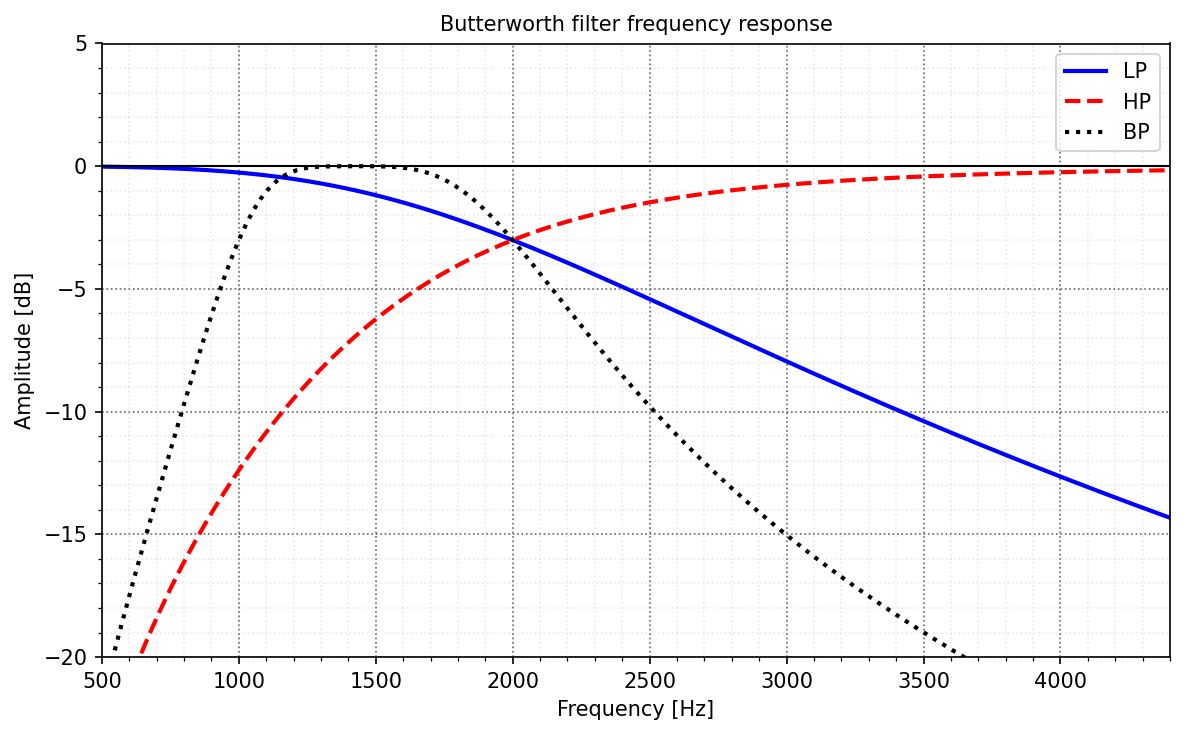

In [10]:
fig = plt.figure(figsize=(8,5), dpi=150)
plt.plot(f_lp, 20 * np.log10(abs(h_lp+eps)),'b-',label='LP')
plt.plot(f_hp, 20 * np.log10(abs(h_hp+eps)),'r--',label='HP')
plt.plot(f_bp, 20 * np.log10(abs(h_bp+eps)),'k:',label='BP')
plt.title('Butterworth filter frequency response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]')
plt.xlim([f_low/2, 1.1*f_high])
plt.ylim([-20, 5])
bm.nicegrid()
plt.legend()
plt.show()

## Find Spectrum of filtered time data to confirm consistent with expectations

In [11]:
# Apply filters to data
yf_lp = lfilter(b_low, a_low, y_bl)
yf_hp = lfilter(b_high, a_high, y_bl)
yf_bp = lfilter(b_bp, a_bp, y_bl)

Y_lp_fft = fft(yf_lp)
Y_hp_fft = fft(yf_hp)
Y_bp_fft = fft(yf_bp)

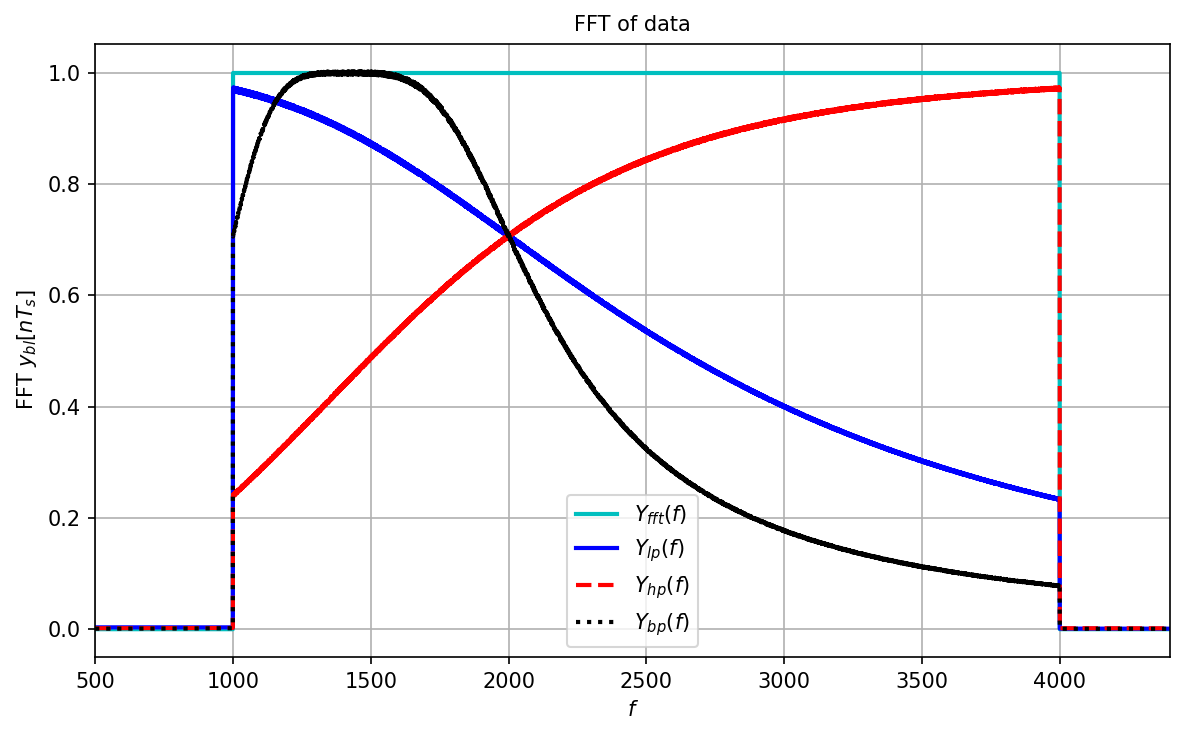

In [12]:
fig, ax1 = plt.subplots(1,1, figsize=(8,5), dpi=150)
ax1.plot(f_bl[0:N//2], np.abs(Y_bl_fft[0:N//2]),'c-')
ax1.plot(f_bl[0:N//2], np.abs(Y_lp_fft[0:N//2]),'b-')
ax1.plot(f_bl[0:N//2], np.abs(Y_hp_fft[0:N//2]),'r--')
ax1.plot(f_bl[0:N//2], np.abs(Y_bp_fft[0:N//2]),'k:')
ax1.set_ylabel(r'FFT $y_{bl}[nT_s]$')
ax1.set_xlabel('$f$')
ax1.set_xlim([int(f_low)/2, 1.1*int(f_high)])
ax1.legend([r'$Y_{fft}(f)$', r'$Y_{lp}(f)$', r'$Y_{hp}(f)$', r'$Y_{bp}(f)$'])
ax1.set_title('FFT of data')
plt.show()

## Ideal filtering in the frequency domain (zero the bins)
Filtering is just **multiplication in the frequency domain**. Instead of designing a time-domain Butterworth filter, we can multiply the spectrum by a 0/1 mask (a "brick-wall" ideal filter) and inverse-transform back. This gives a *perfect* cutoff, but it is non-causal and can produce ringing / wrap-around (it is a **circular** convolution in time), which is why realizable filters like the Butterworth use a smooth roll-off instead.

In [13]:
# --- Ideal "brick-wall" filtering done directly in the frequency domain ---
# Filtering = multiplication in the frequency domain, so just zero the FFT bins.
# Use the SAME cutoffs as the Butterworth filters above so the two are comparable.
fc_lp = 2*f_low            # low-pass cutoff
fc_hp = f_high/2           # high-pass cutoff
bp_lo, bp_hi = omega0, omega1   # band-pass edges (reused from the butter cell)

# f_bl = fftfreq(...) is signed, so |f| <= fc masks the +ve AND -ve halves
# together -> conjugate symmetry is preserved -> ifft stays real.
mask_lp = np.abs(f_bl) <= fc_lp
mask_hp = np.abs(f_bl) >= fc_hp
mask_bp = (np.abs(f_bl) >= bp_lo) & (np.abs(f_bl) <= bp_hi)

Yi_lp = Y_bl_fft * mask_lp
Yi_hp = Y_bl_fft * mask_hp
Yi_bp = Y_bl_fft * mask_bp

yi_lp = np.real(ifft(Yi_lp))   # filtered signals in the time domain (real)
yi_hp = np.real(ifft(Yi_hp))
yi_bp = np.real(ifft(Yi_bp))

# sanity check: imaginary part should be ~0 because the mask is symmetric in +/- f
print('max |imag| after LP ifft =', np.max(np.abs(np.imag(ifft(Yi_lp)))))

max |imag| after LP ifft = 8.094808515196068e-19


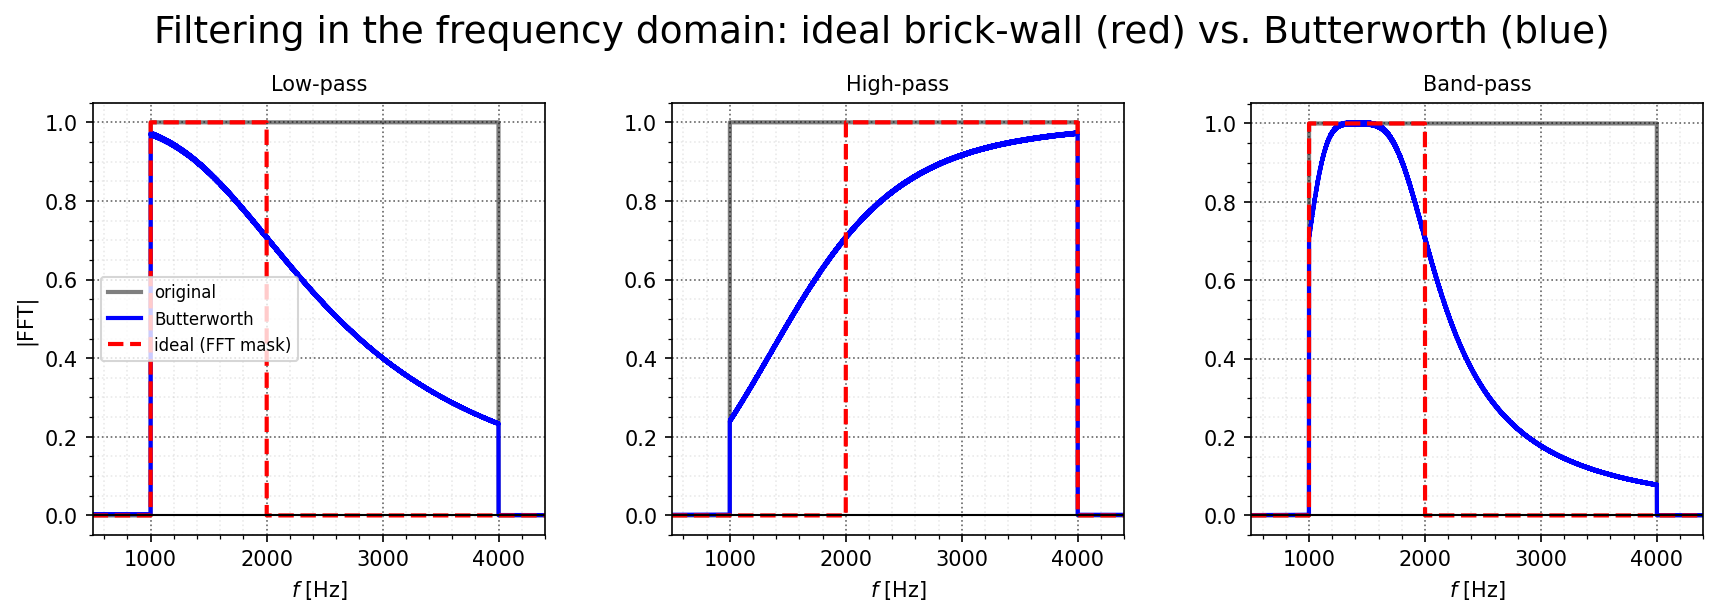

In [14]:
# Compare the ideal frequency-domain mask vs. the realizable Butterworth filter
fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=150)
fig.tight_layout(pad=3)
specs = [('Low-pass',  Y_lp_fft, Yi_lp),
         ('High-pass', Y_hp_fft, Yi_hp),
         ('Band-pass', Y_bp_fft, Yi_bp)]
for ax, (name, Ybw, Yideal) in zip(axes, specs):
    ax.plot(f_bl[0:N//2], np.abs(Y_bl_fft[0:N//2]), color='k', alpha=0.5, label='original')
    ax.plot(f_bl[0:N//2], np.abs(Ybw[0:N//2]),     'b-',  label='Butterworth')
    ax.plot(f_bl[0:N//2], np.abs(Yideal[0:N//2]),  'r--', label='ideal (FFT mask)')
    ax.set_title(name)
    ax.set_xlabel('$f$ [Hz]')
    ax.set_xlim([f_low/2, 1.1*f_high])
    bm.nicegrid(ax)
axes[0].set_ylabel('|FFT|')
axes[0].legend(fontsize=8)
fig.suptitle('Filtering in the frequency domain: ideal brick-wall (red) vs. Butterworth (blue)', y=1.03)
plt.savefig('figs/T8_filt_1.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
from scipy.io.wavfile import write 
import IPython.display as ipd
from numpy import real, float32  # Ensure necessary imports
write("data/y_fft_flat.wav", fs, (real(y_bl) / np.max(abs(y_bl))).astype(float32))
ipd.display(ipd.Markdown("**Original signal (unfiltered)**"))
ipd.Audio("data/y_fft_flat.wav", rate=fs)

**Original signal (unfiltered)**

In [16]:
write("data/yf_lp_fft_flat.wav", fs, np.real(yf_lp/np.max(yf_lp)).astype(np.float32))
ipd.display(ipd.Markdown("**Butterworth low-pass output**"))
ipd.Audio('data/yf_lp_fft_flat.wav', rate = fs)

**Butterworth low-pass output**

In [17]:
write("data/yi_lp_flat.wav", fs, (np.real(yi_lp)/np.max(np.abs(yi_lp))).astype(np.float32))
ipd.display(ipd.Markdown("**Ideal low-pass output**"))
ipd.Audio("data/yi_lp_flat.wav", rate=fs)

**Ideal low-pass output**

In [18]:
write("data/yf_hp_fft_flat.wav", fs, np.real(yf_hp/np.max(yf_hp)).astype(np.float32))
ipd.display(ipd.Markdown("**Butterworth high-pass output**"))
ipd.Audio('data/yf_hp_fft_flat.wav', rate = fs)

**Butterworth high-pass output**

In [19]:
write("data/yi_hp_flat.wav", fs, (np.real(yi_hp)/np.max(np.abs(yi_hp))).astype(np.float32))
ipd.display(ipd.Markdown("**Ideal high-pass output**"))
ipd.Audio("data/yi_hp_flat.wav", rate=fs)

**Ideal high-pass output**

In [20]:
write("data/yf_bp_fft_flat.wav", fs, np.real(yf_bp/np.max(yf_bp)).astype(np.float32))
ipd.display(ipd.Markdown("**Butterworth band-pass output**"))
ipd.Audio('data/yf_bp_fft_flat.wav', rate = fs)

**Butterworth band-pass output**

In [21]:
write("data/yi_bp_flat.wav", fs, (np.real(yi_bp)/np.max(np.abs(yi_bp))).astype(np.float32))
ipd.display(ipd.Markdown("**Ideal band-pass output**"))
ipd.Audio("data/yi_bp_flat.wav", rate=fs)

**Ideal band-pass output**